In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt
%matplotlib inline

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

2025-07-25 13:20:07,725	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the four classes:
# white tarp, black tarp, aspen, conifer

In [2]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
conifer = home+'test_roi/conifer/'
cal = home+'test_roi/calTarp/'

rtes = ['sRTMnet', 'MODTRAN']

dir_insitu = home+'insitu/'

In [3]:
# define cal tarp roi

bboxes = {}
bboxes['WhiteTarp'] = [31,20,35,26]
bboxes['BlackTarp'] = [41,21,45,27]
bboxes

{'WhiteTarp': [31, 20, 35, 26], 'BlackTarp': [41, 21, 45, 27]}

In [7]:
fp = glob(os.path.join(home, 'conifer', 'subset', '*_rdn.hdr'))
fp

[]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.067847736..2.0].


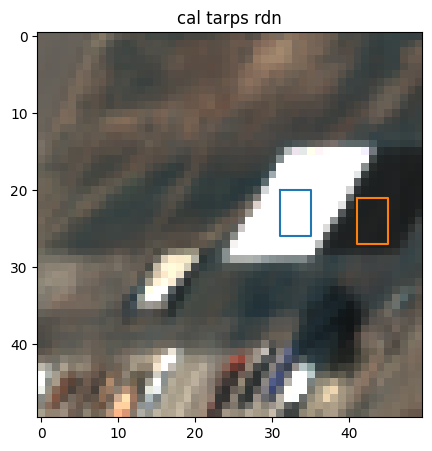

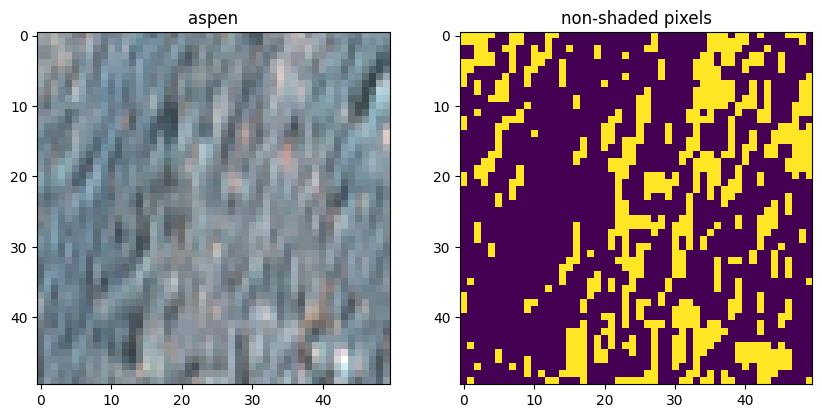

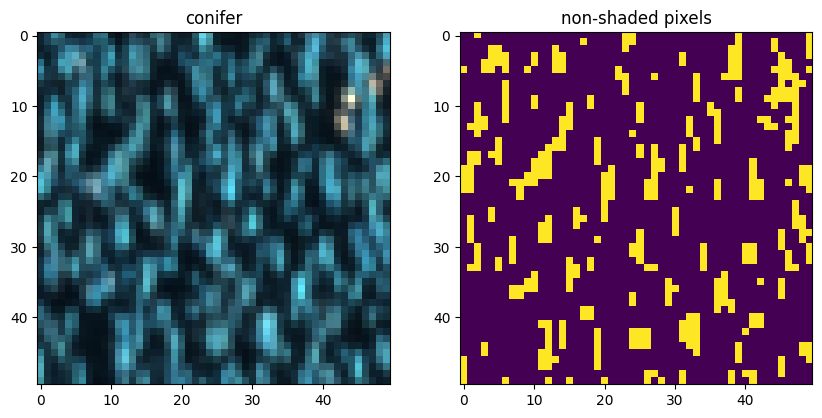

In [8]:
# visualize full rdn w regions averaged to single pixels

# cal tarps
fig = plt.figure(figsize=(10,5))
fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
plt.imshow(rgb / np.max(rgb, axis=(0, 1))*2)
for k, (minx, miny, maxx, maxy) in bboxes.items():
    x = [minx, maxx, maxx, minx, minx]
    y = [miny, miny, maxy, maxy, miny]
    plt.plot(x, y, label=k)
plt.title('cal tarps rdn')

# aspen, conifer
for veg in ['aspen', 'conifer']:
    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn.hdr'))[0]
    rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
    axs[0].set_title(veg)
    lit = np.sum(rgb, axis=2)
    valid = lit > 5
    axs[1].imshow(valid)
    axs[1].set_title('non-shaded pixels')
    plt.show()

In [11]:
# prepare representative single pixels

rdn = {}
obs = {}
loc = {}
for k in bboxes.keys():
    minx, miny, maxx, maxy = bboxes[k]
    fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
    rdn[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_rdn_obs.hdr'))[0]
    obs[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    fp = glob(os.path.join(cal, 'subset', '*_rdn_igm.hdr'))[0]
    loc[k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
for veg in ['aspen', 'conifer']:
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn.hdr'))[0]
    tmp = envi.open(fp).open_memmap(interleave='bip').copy()
    shaded = np.sum(tmp[...,[60,40,30]], axis=2) < 5
    tmp[shaded, :] = np.nan
    rdn[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn_obs.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    obs[veg] = np.nanmean(tmp, axis=(0,1))
    fp = glob(os.path.join(home, 'test_roi', veg, 'subset', '*_rdn_igm.hdr'))[0]
    tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
    tmp[shaded, :] = np.nan
    loc[veg] = np.nanmean(tmp, axis=(0,1))

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [7.0404, 9.7516]})


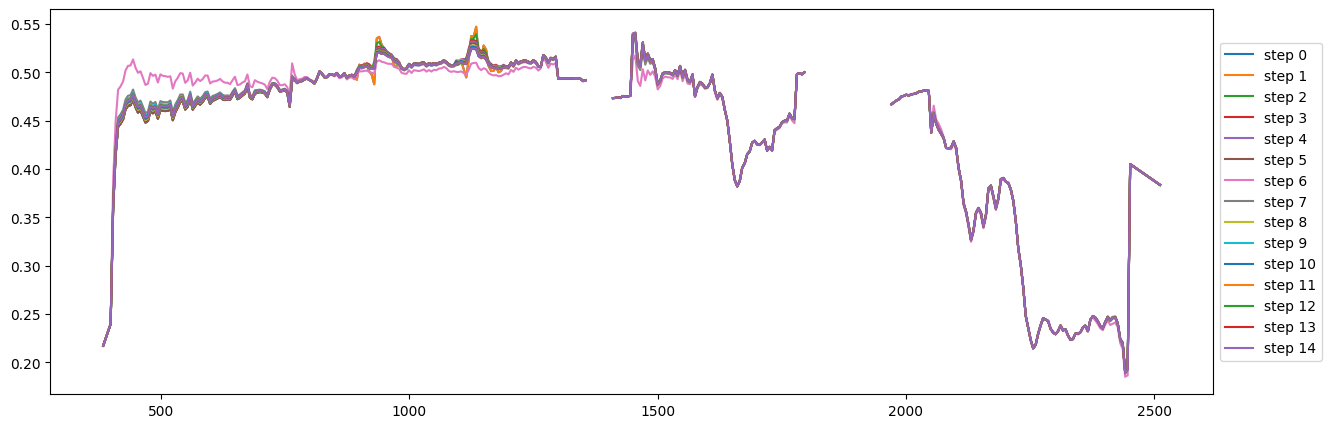

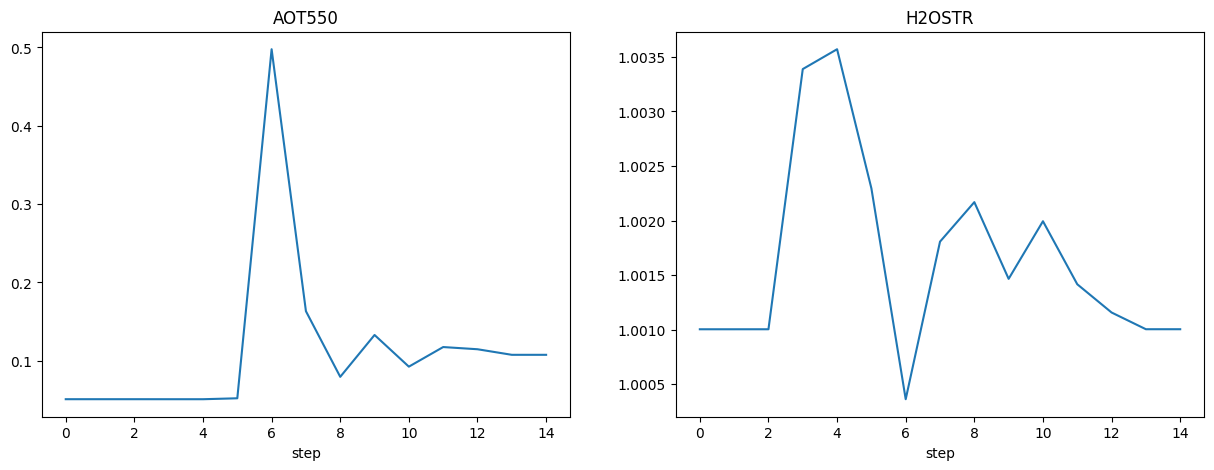

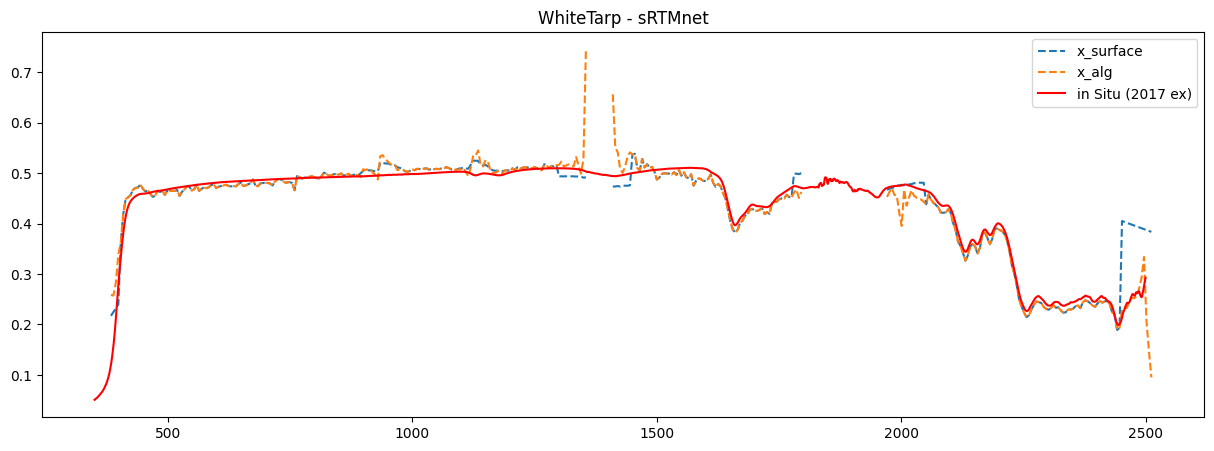

In [6]:
# white tarp, sRTMnet

rte = 'sRTMnet'
k = 'WhiteTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions

# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_whiteTarp_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_MODTRAN/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_MODTRAN/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AERFRAC_2': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [7.0404, 9.7516]})


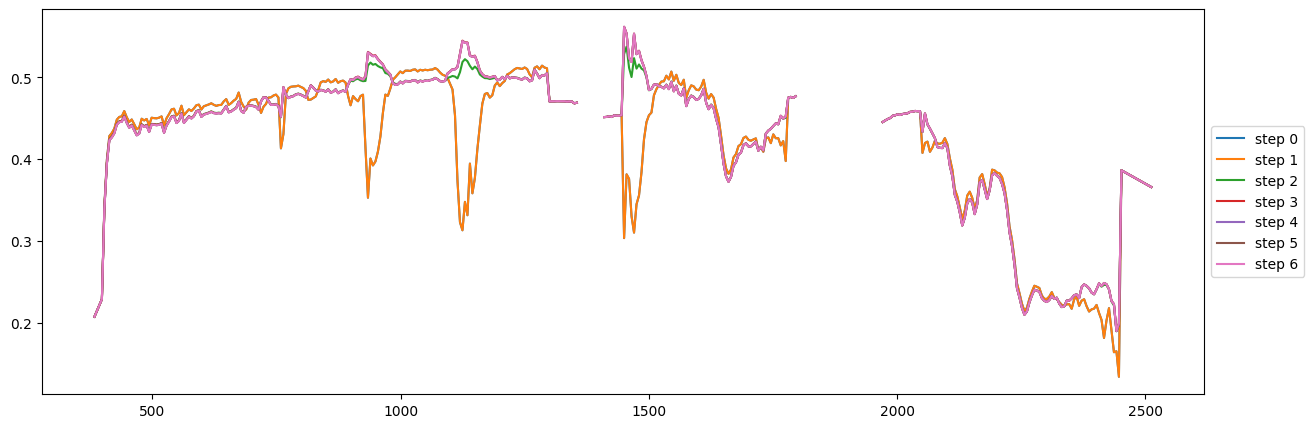

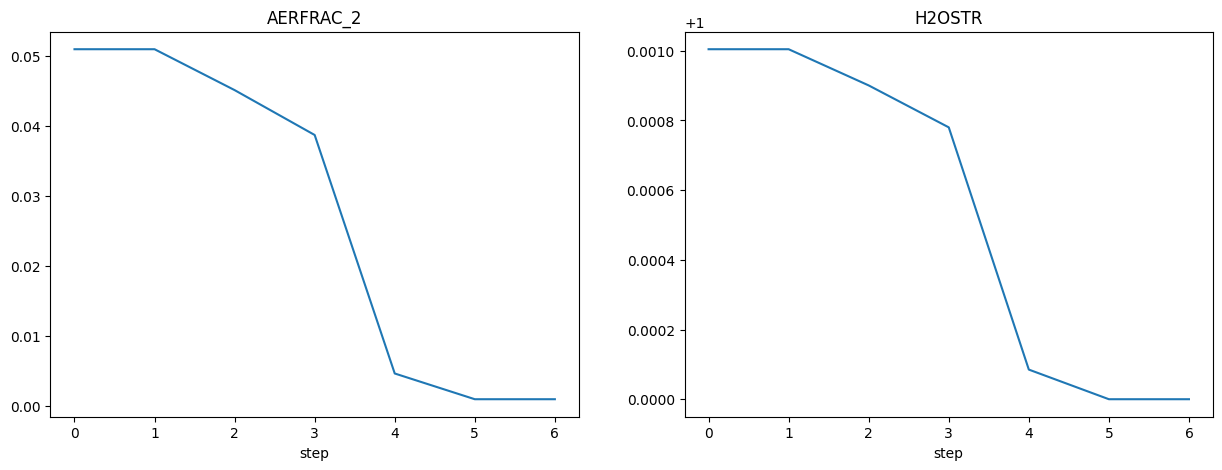

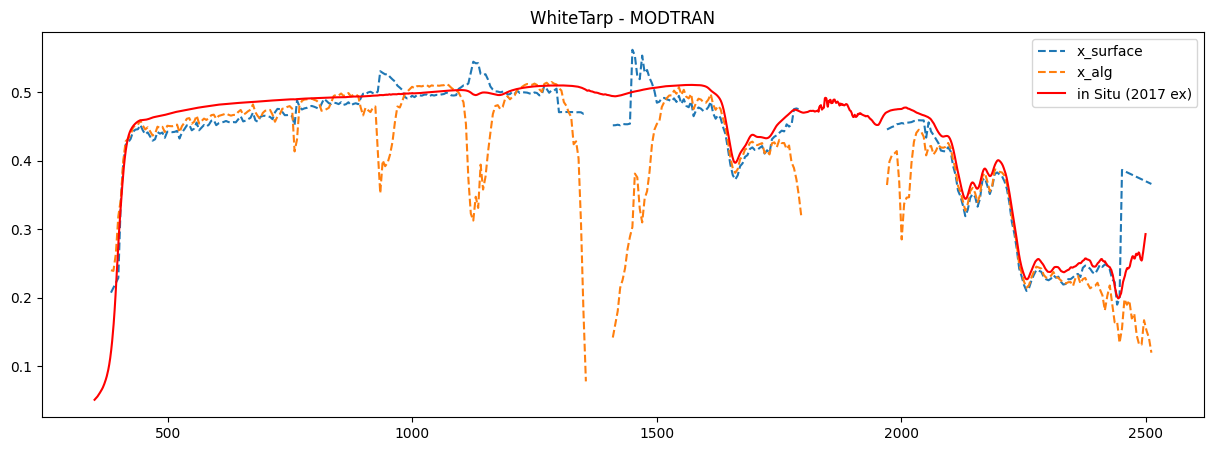

In [8]:
# white tarp, modtran

rte = 'MODTRAN'
k = 'WhiteTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_whiteTarp_modtran = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [7.0404, 9.7516]})


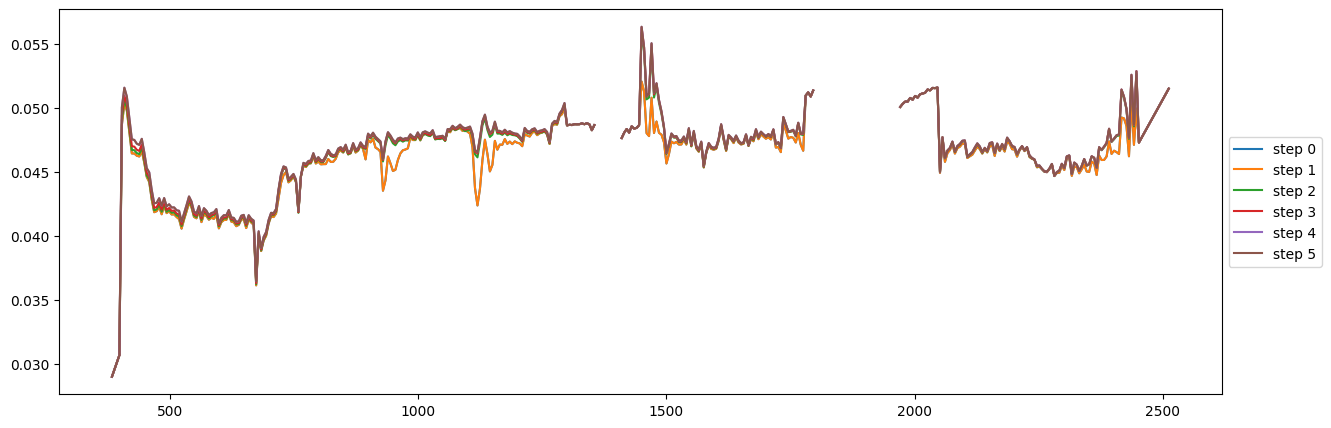

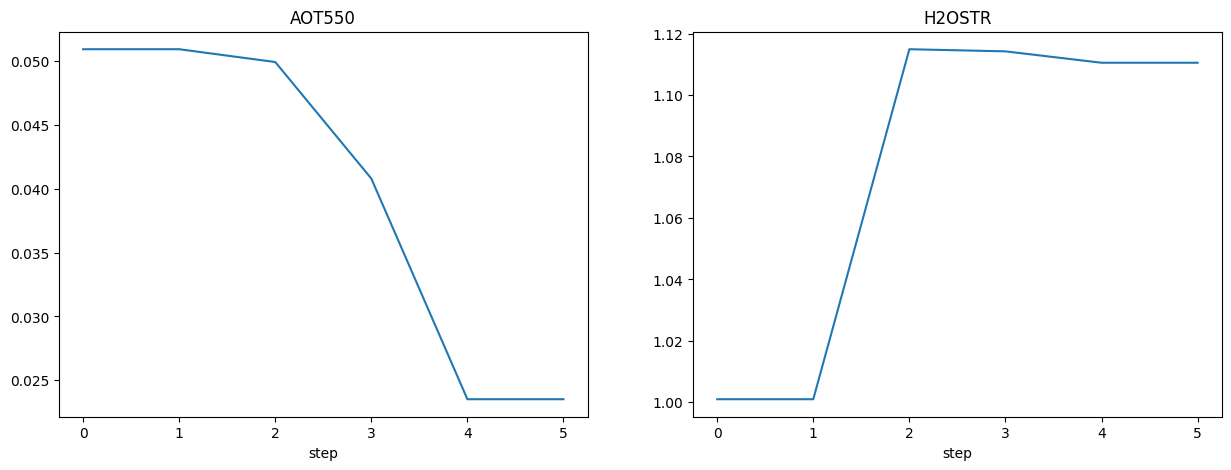

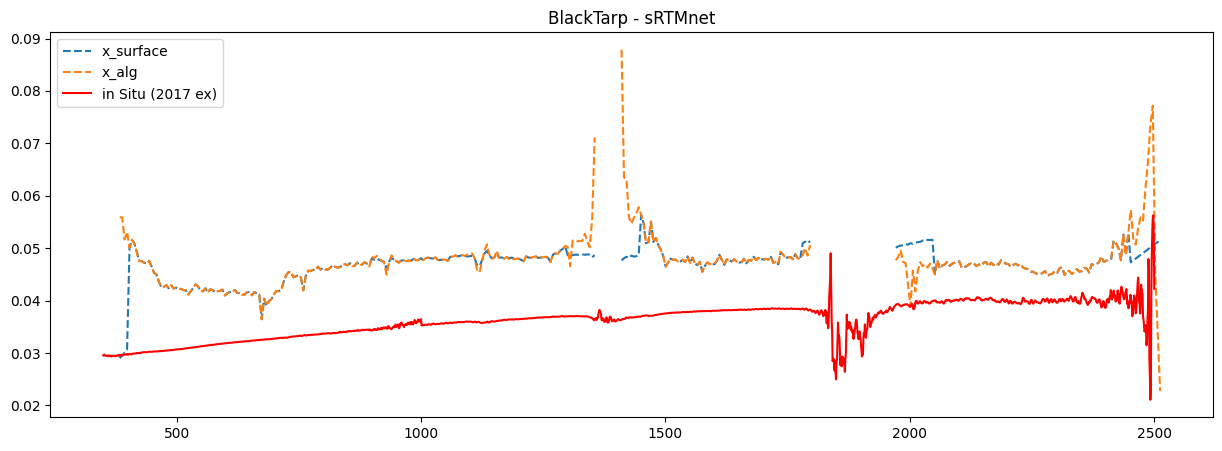

In [9]:
# black tarp, sRTMnet

rte = 'sRTMnet'
k = 'BlackTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_blackTarp_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_MODTRAN/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_MODTRAN/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AERFRAC_2': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [7.0404, 9.7516]})


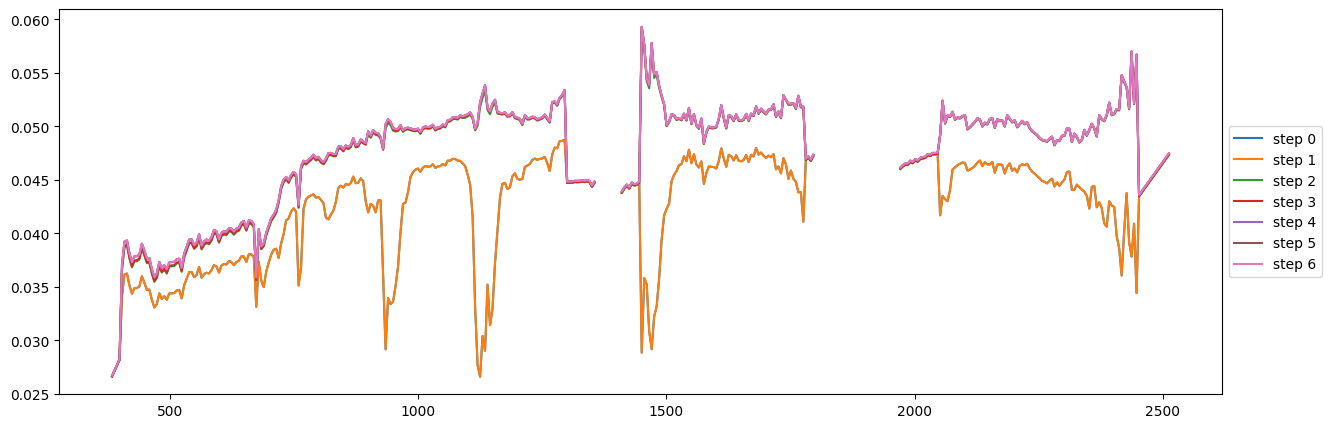

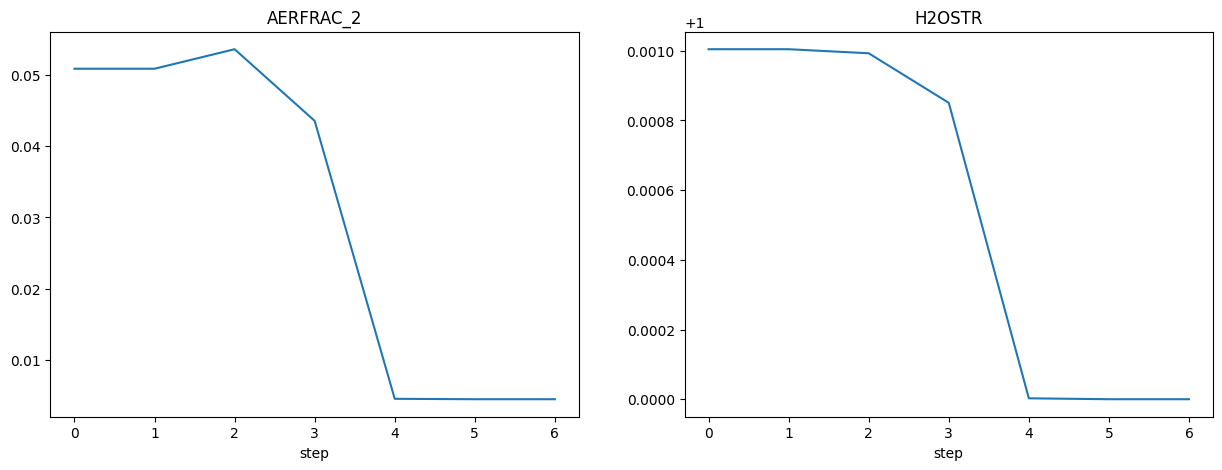

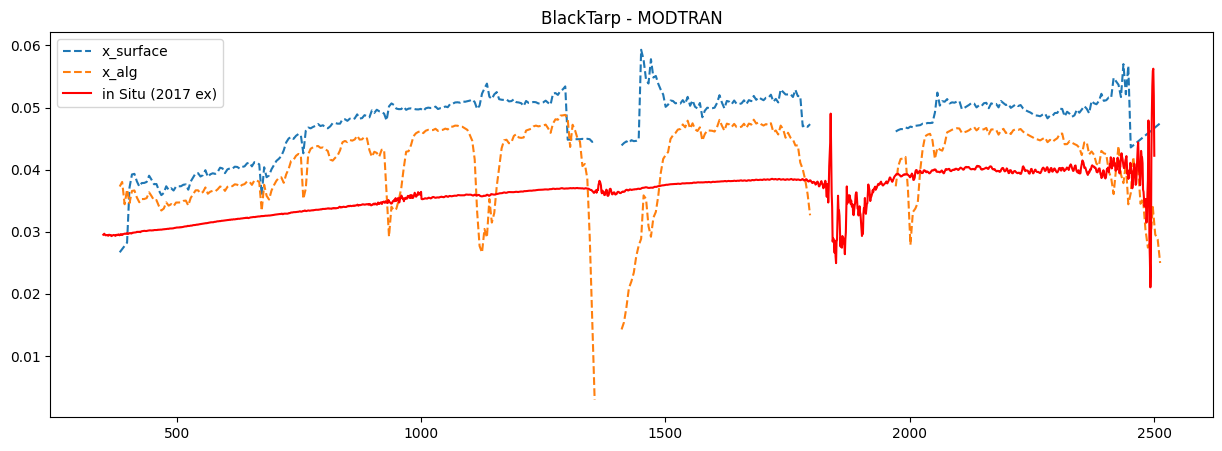

In [10]:
# black tarp, modtran

rte = 'MODTRAN'
k = 'BlackTarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_blackTarp_modtran = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8]})


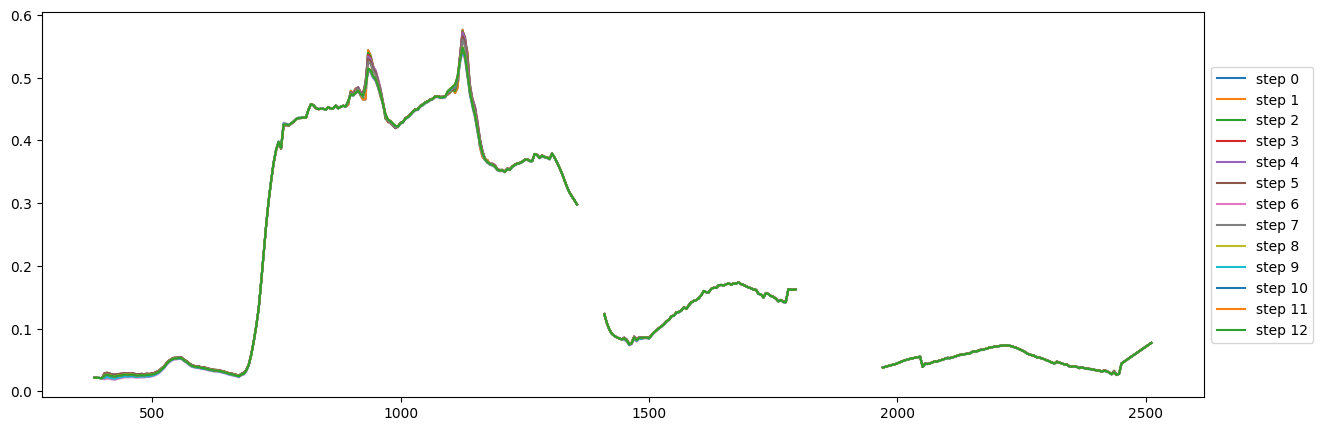

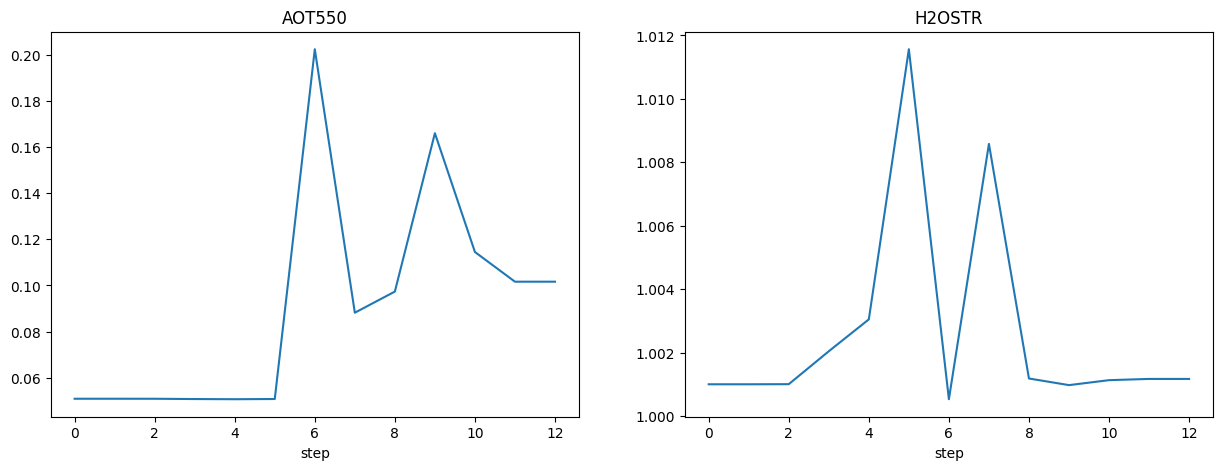

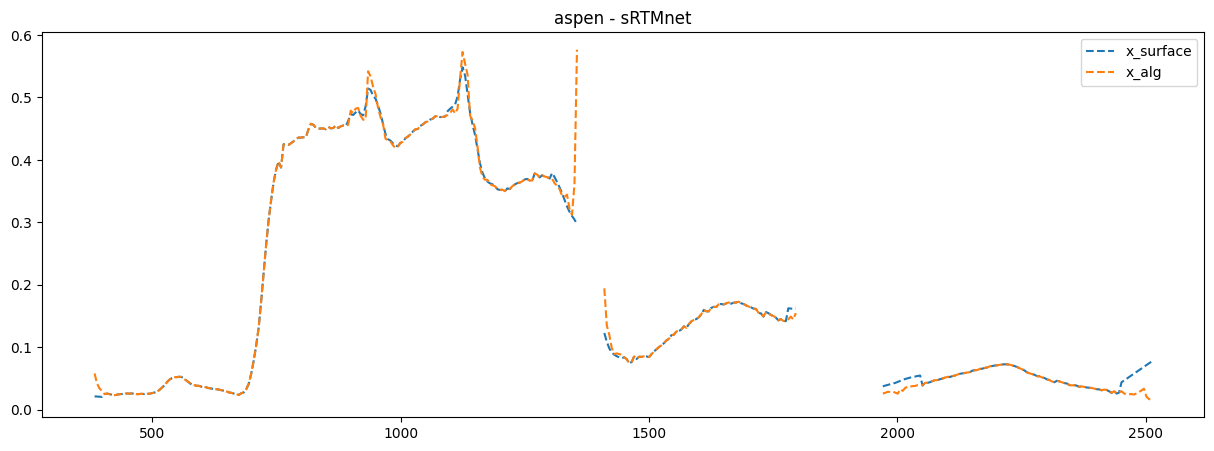

In [11]:
# aspen, srtmnet

rte = 'sRTMnet'
k = 'aspen'
fol = aspen

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
# in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
# plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_aspen_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_MODTRAN/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_MODTRAN/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AERFRAC_2': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8]})


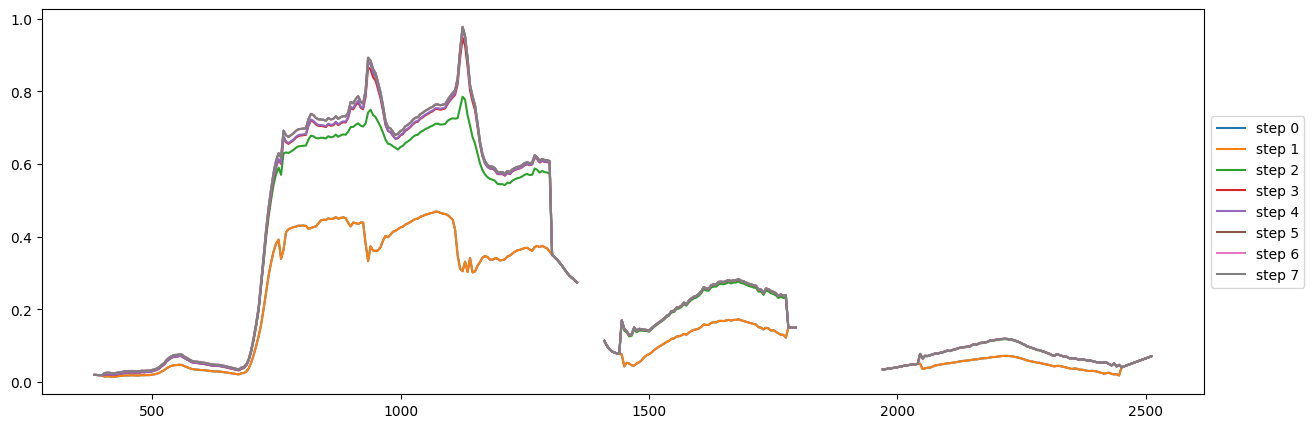

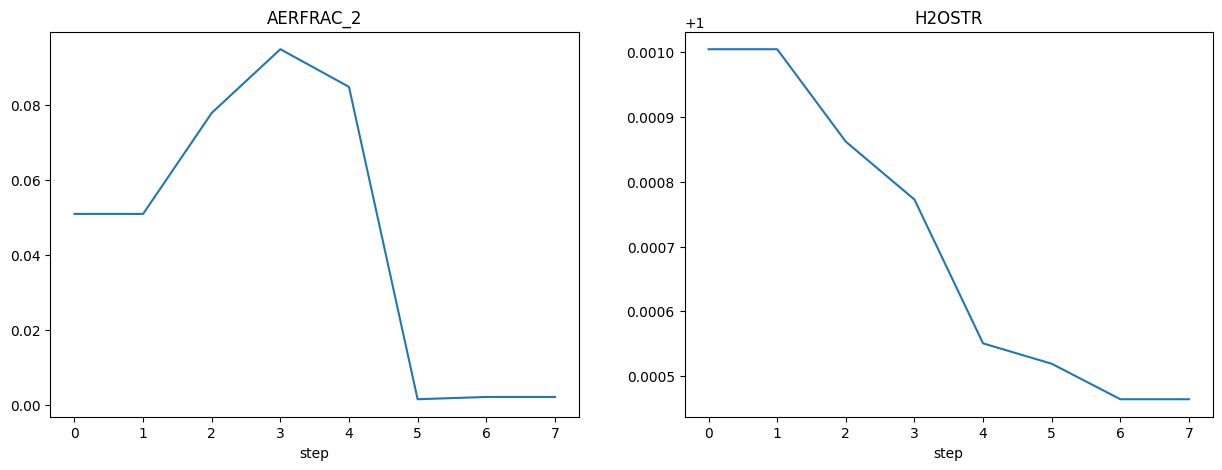

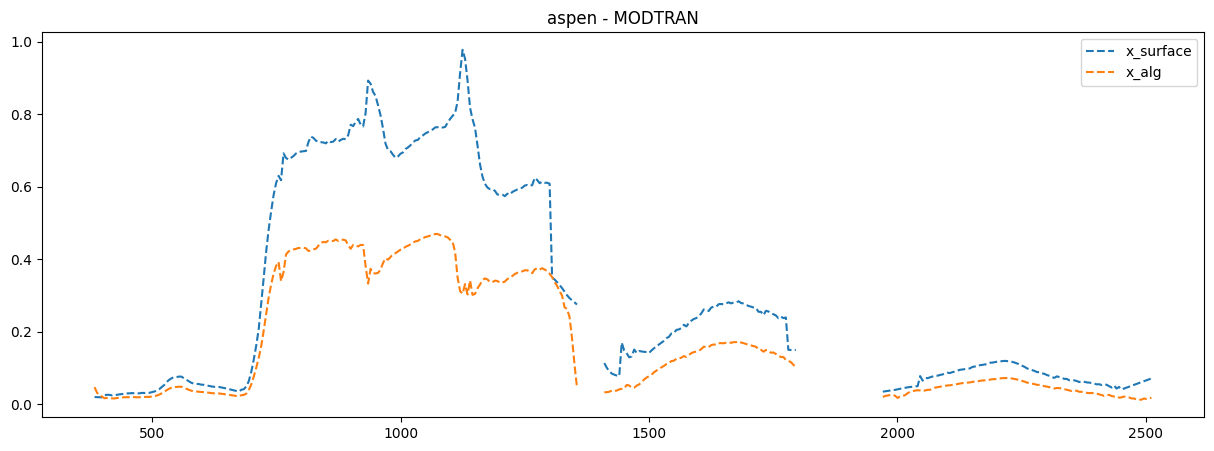

In [12]:
# aspen, modtran

rte = 'MODTRAN'
k = 'aspen'
fol = aspen

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
# in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
# plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_aspen_modtran = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/conifer/NIS01_20180619_160339_sRTMnet/config/NIS01_20180619_160339_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/conifer/NIS01_20180619_160339_sRTMnet/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AOT550': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [8.7846, 11.4944]})


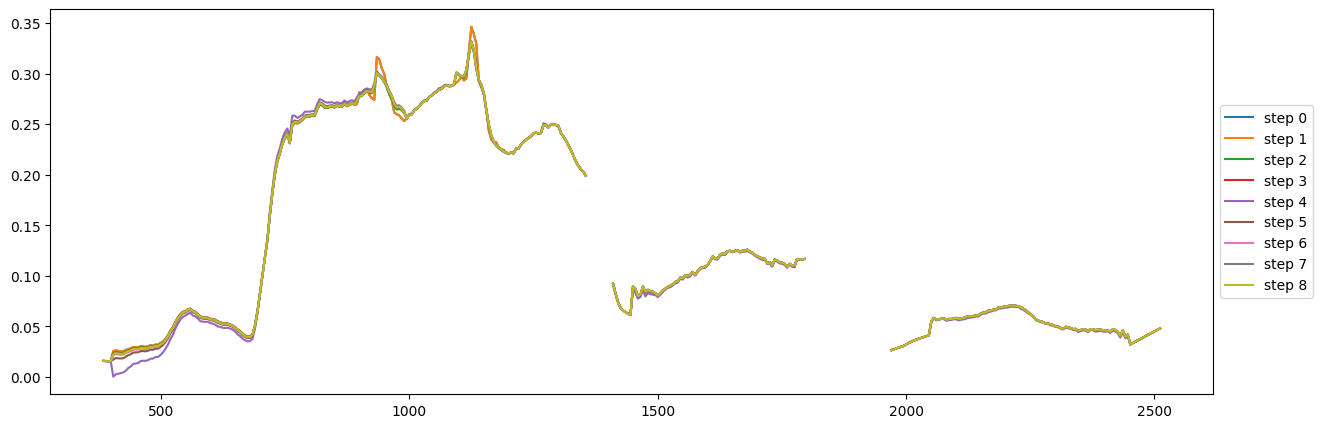

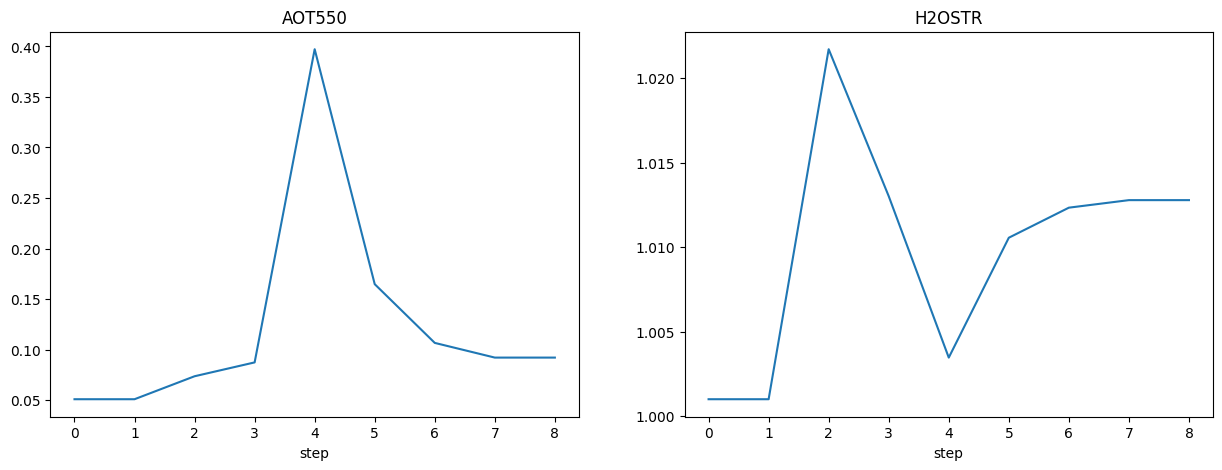

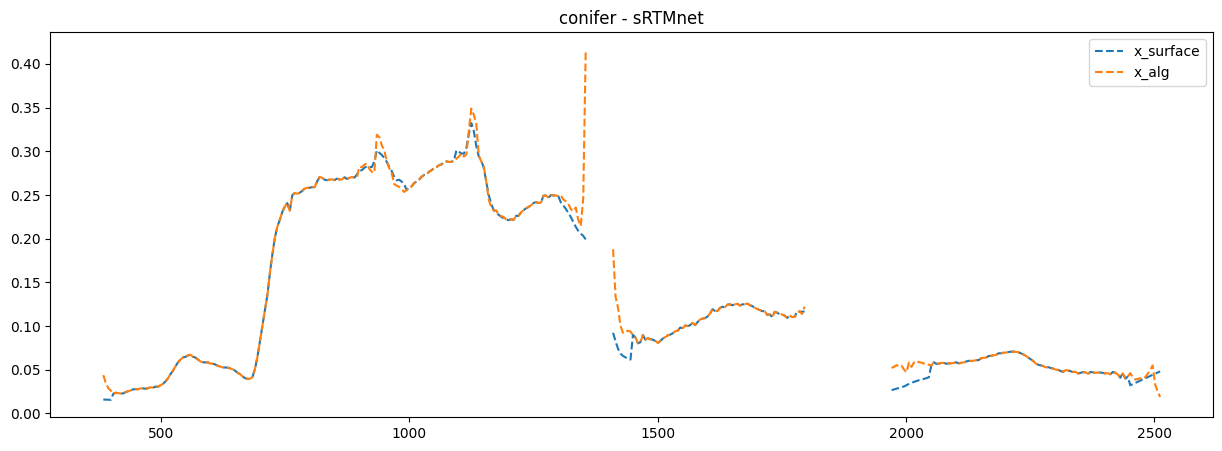

In [13]:
# conifer, srtmnet

rte = 'sRTMnet'
k = 'conifer'
fol = conifer

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
# in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
# plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_conifer_srtmnet = x_alg.copy()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/conifer/NIS01_20180619_160339_MODTRAN/config/NIS01_20180619_160339_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/conifer/NIS01_20180619_160339_MODTRAN/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file: OrderedDict({'AERFRAC_2': [0.001, 0.1008, 0.2006, 0.3004, 0.4002, 0.5], 'H2OSTR': [1.0, 1.2, 1.4, 1.6, 1.8], 'observer_zenith': [8.7846, 11.4944]})


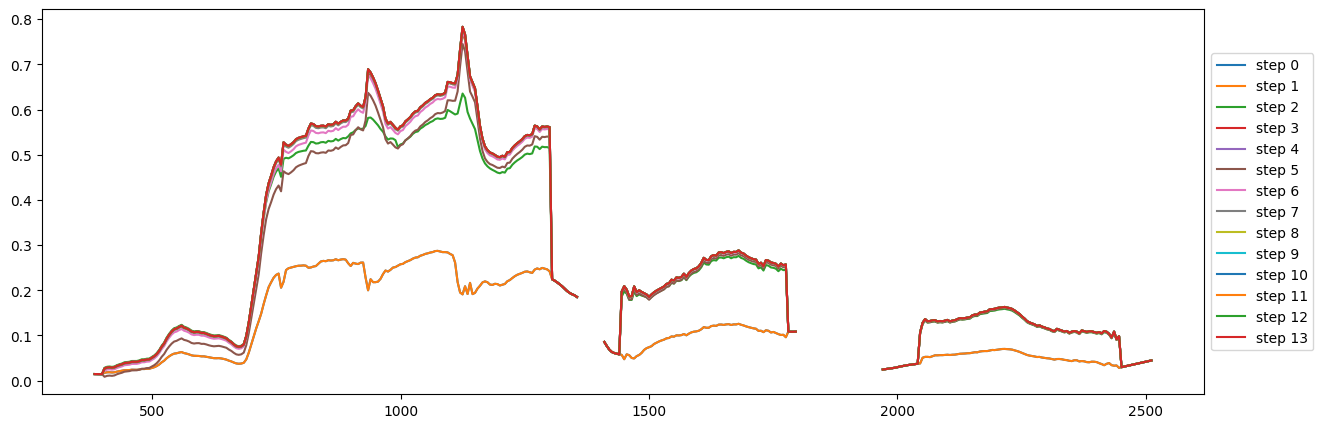

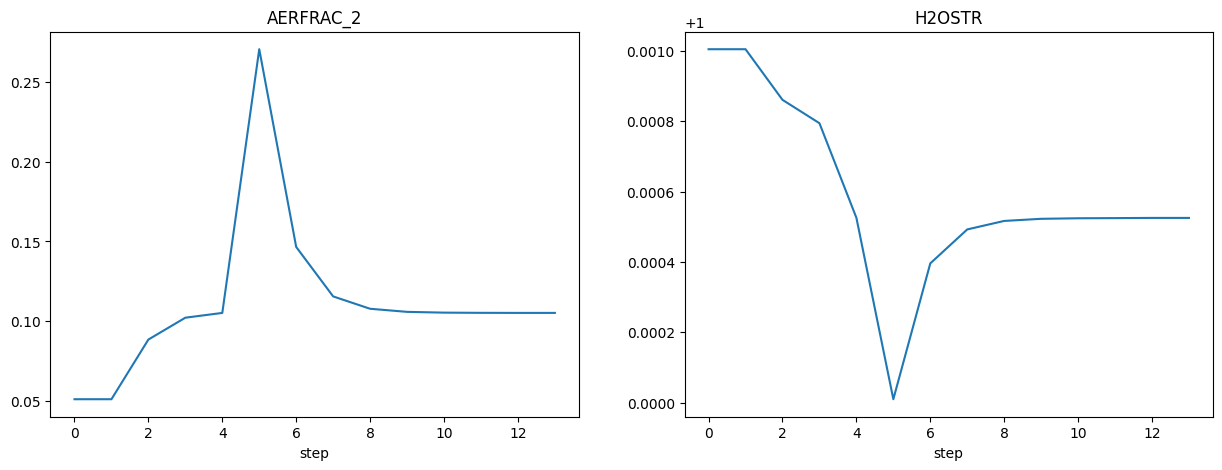

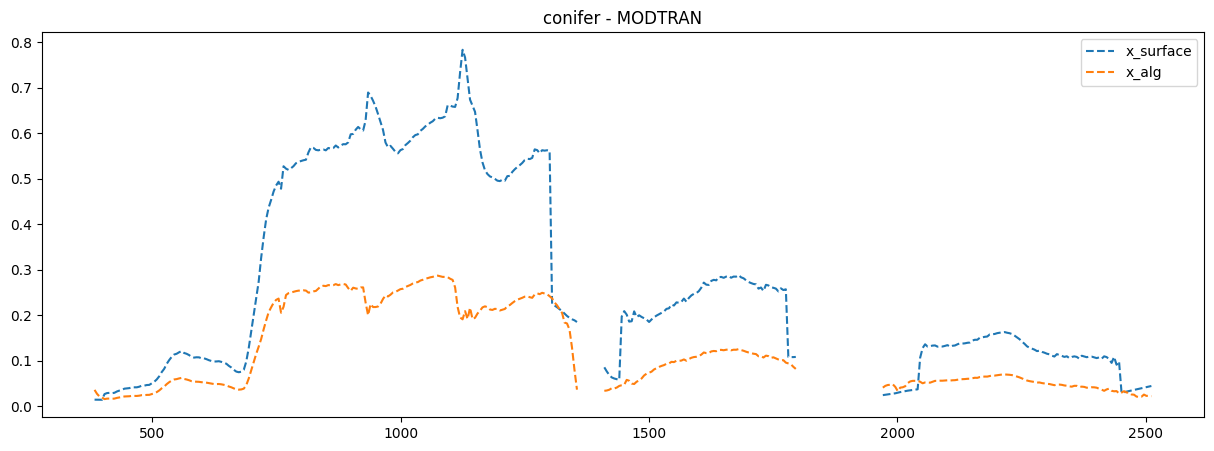

In [14]:
# conifer, modtran

rte = 'MODTRAN'
k = 'conifer'
fol = conifer

# load, update config file
fp = glob(os.path.join(fol, f'*{rte}', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'surface.mat') # not totally clear to me why we update this, is original surface model updated by apply oe before saving to workign dir?
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_rdn_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_rdn_igm'))[0]

# set up forward model, io, inversion according to config
fm = ForwardModel(config) # loads pre-built LUT
io = IO(config, fm)
inv = Inversion(config, fm)

# load the isofit geometry representation of the single pixel
geom = Geometry(obs=obs[k], loc=loc[k])

# run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and obs rdn
states=inv.invert(rdn[k], geom)

# get solutions converged upon at the final step
x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])

# do a final inversion with the above solutions to get rfl
x_alg, Ls, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, 
                                     x_surface, x_RT, x_instrument,
                                     rdn[k], geom)

# visualize solutions
# surface
def closest_wl(mv):
    return np.argmin(np.abs(io.meas_wl-mv))
wl = io.meas_wl.copy()
wl[closest_wl(1360):closest_wl(1410)] = np.nan
wl[closest_wl(1800):closest_wl(1970)] = np.nan
fig = plt.figure(figsize=(15,5))
for n in range(0, states.shape[0]):
    lab = f'step {n}'
    plt.plot(wl, states[n, :-2], label=lab)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

# rt
labs = config.forward_model.radiative_transfer.radiative_transfer_engines[0].statevector_names
states_rt = states[:, -2:]
fig, axs = plt.subplots(ncols=2, figsize=(15,5))
for i in [0,1]:
    axs[i].plot(range(states_rt.shape[0]), states_rt[:,i])
    axs[i].set_title(labs[i])
    axs[i].set_xlabel('step')
plt.show()

# final rfl solution w/ in situ (still from 2017 Pasadena ex)
# in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(15,5))
plt.plot(wl, x_surface, label='x_surface', ls='--')
plt.plot(wl, x_alg, label='x_alg', ls='--')
# plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(f'{k} - {rte}')
plt.legend()
plt.show()

x_alg_conifer_modtran = x_alg.copy()

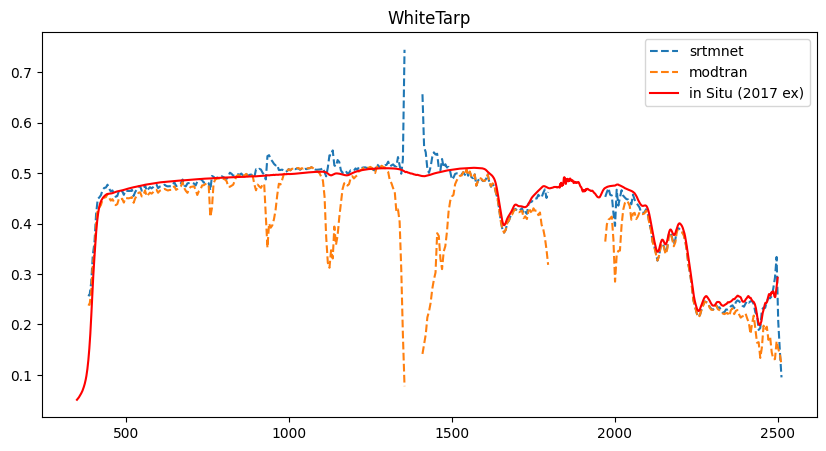

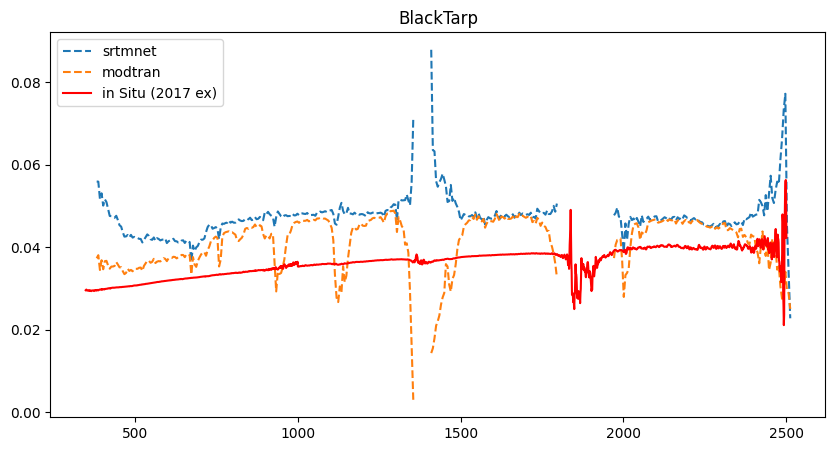

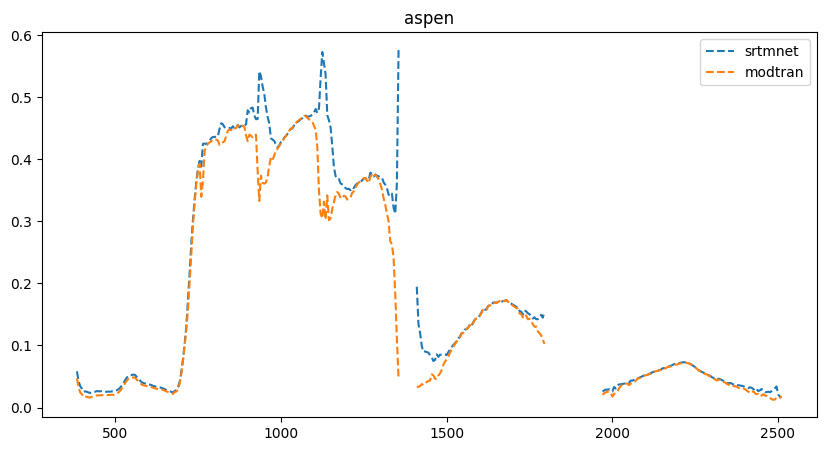

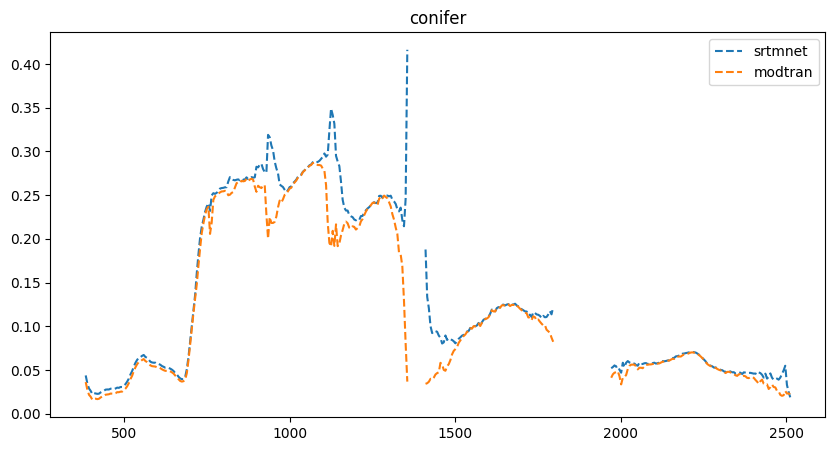

In [24]:
# compare sRTMnet, modtran retrievals

# cal tarps
k = 'WhiteTarp'
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(10,5))
plt.plot(wl, x_alg_whiteTarp_srtmnet, label='srtmnet', ls='--')
plt.plot(wl, x_alg_whiteTarp_modtran, label='modtran', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(k)
plt.legend()
plt.show()

k = 'BlackTarp'
in_situ = np.genfromtxt(os.path.join(dir_insitu, f'{k}01', 'Data', f'{k}01_Refl.dat'), skip_header=3)
fig = plt.figure(figsize=(10,5))
plt.plot(wl, x_alg_blackTarp_srtmnet, label='srtmnet', ls='--')
plt.plot(wl, x_alg_blackTarp_modtran, label='modtran', ls='--')
plt.plot(in_situ[:,0], in_situ[:,1], label=f'in Situ (2017 ex)',c='red')
plt.title(k)
plt.legend()
plt.show()

k = 'aspen'
fig = plt.figure(figsize=(10,5))
plt.plot(wl, x_alg_aspen_srtmnet, label='srtmnet', ls='--')
plt.plot(wl, x_alg_aspen_modtran, label='modtran', ls='--')
plt.title(k)
plt.legend()
plt.show()

k = 'conifer'
fig = plt.figure(figsize=(10,5))
plt.plot(wl, x_alg_conifer_srtmnet, label='srtmnet', ls='--')
plt.plot(wl, x_alg_conifer_modtran, label='modtran', ls='--')
plt.title(k)
plt.legend()
plt.show()